In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [17]:
df = pd.read_csv("SampleSuperstore.csv")

print(df.head())


  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  Price  Customer ID         Country  
0  01/12/10 08:26   2.55      17850.0  United Kingdom  
1  01/12/10 08:26   3.39      17850.0  United Kingdom  
2  01/12/10 08:26   2.75      17850.0  United Kingdom  
3  01/12/10 08:26   3.39      17850.0  United Kingdom  
4  01/12/10 08:26   3.39      17850.0  United Kingdom  


In [18]:
print(df.shape)


(541910, 8)


In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


In [20]:
#Check Missing Values
print(df.isnull().sum())

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64


In [21]:
#Remove Missing Customer IDs
df = df.dropna(subset=['Customer ID'])

In [24]:
#Create Revenue Column
df['Revenue'] = df['Quantity'] * df['Price']

In [25]:
print("Total Records:", len(df))

print("Total Revenue: ₹", round(df['Revenue'].sum(),2))

print("Total Customers:", df['Customer ID'].nunique())

print("Total Products:", df['Description'].nunique())

print("Countries:", df['Country'].nunique())

Total Records: 406830
Total Revenue: ₹ 8300083.81
Total Customers: 4372
Total Products: 3896
Countries: 37


In [26]:
top_products = (
    df.groupby('Description')['Quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53215
JUMBO BAG RED RETROSPOT               45066
ASSORTED COLOUR BIRD ORNAMENT         35314
WHITE HANGING HEART T-LIGHT HOLDER    34147
PACK OF 72 RETROSPOT CAKE CASES       33409
POPCORN HOLDER                        30504
RABBIT NIGHT LIGHT                    27094
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25321
PACK OF 60 PINK PAISLEY CAKE CASES    24163
Name: Quantity, dtype: int64


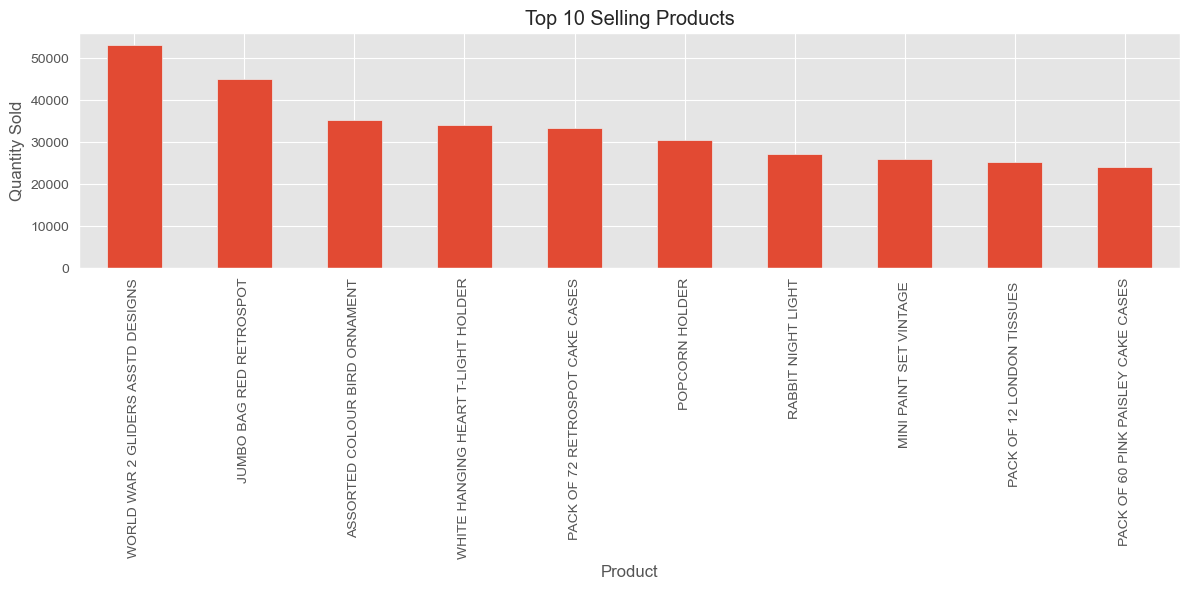

In [27]:
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.tight_layout()
plt.savefig("top_products.png")
plt.show()

In [28]:
#Country-wise Revenue Analysis
country_sales = (
    df.groupby('Country')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(country_sales)

Country
United Kingdom    6767873.394
Netherlands        284661.540
EIRE               250285.220
Germany            221698.210
France             196730.840
Australia          137077.270
Switzerland         55739.400
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64


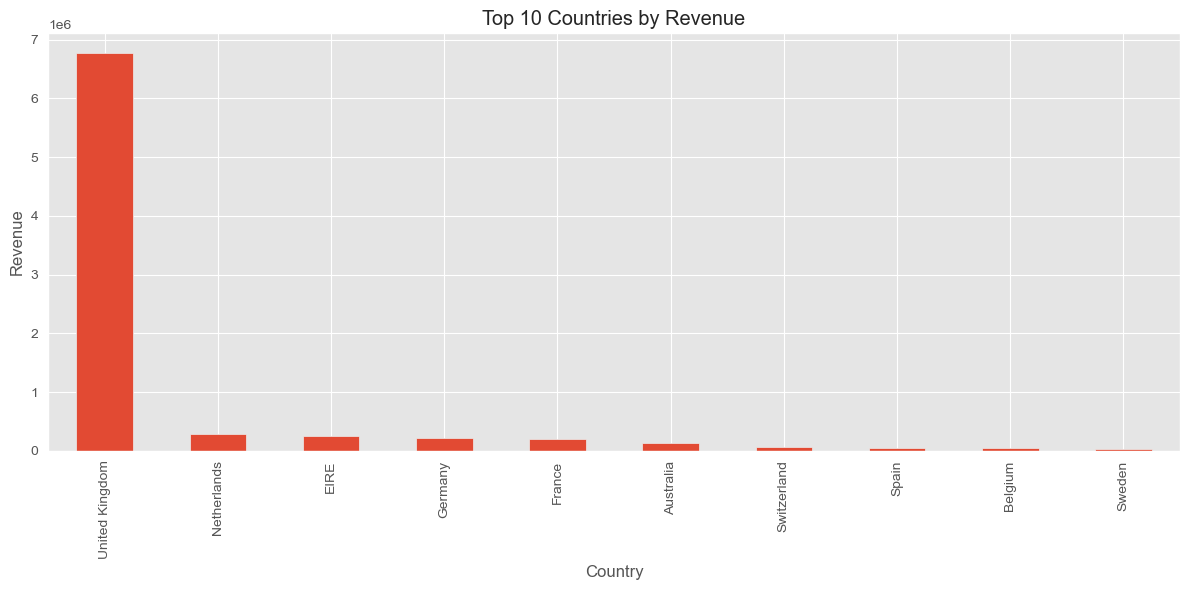

In [29]:
plt.figure(figsize=(12,6))

country_sales.plot(kind='bar')

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.tight_layout()
plt.savefig("country_sales.png")
plt.show()

In [30]:
#Monthly Sales Trend

df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = (
    df.groupby('Month')['Revenue']
      .sum()
)

print(monthly_sales)

Month
2010-01      46051.260
2010-02      45775.430
2010-03      22598.460
2010-05      31380.600
2010-06      30465.080
2010-07      53125.990
2010-08      38048.680
2010-09      37177.850
2010-10      32005.350
2010-12     217975.320
2011-01     510308.100
2011-02     479089.930
2011-03     617490.300
2011-04     556556.961
2011-05     704359.400
2011-06     663888.110
2011-07     706117.571
2011-08     583211.860
2011-09     901398.352
2011-10     820252.470
2011-11    1004792.270
2011-12     198014.470
Freq: M, Name: Revenue, dtype: float64


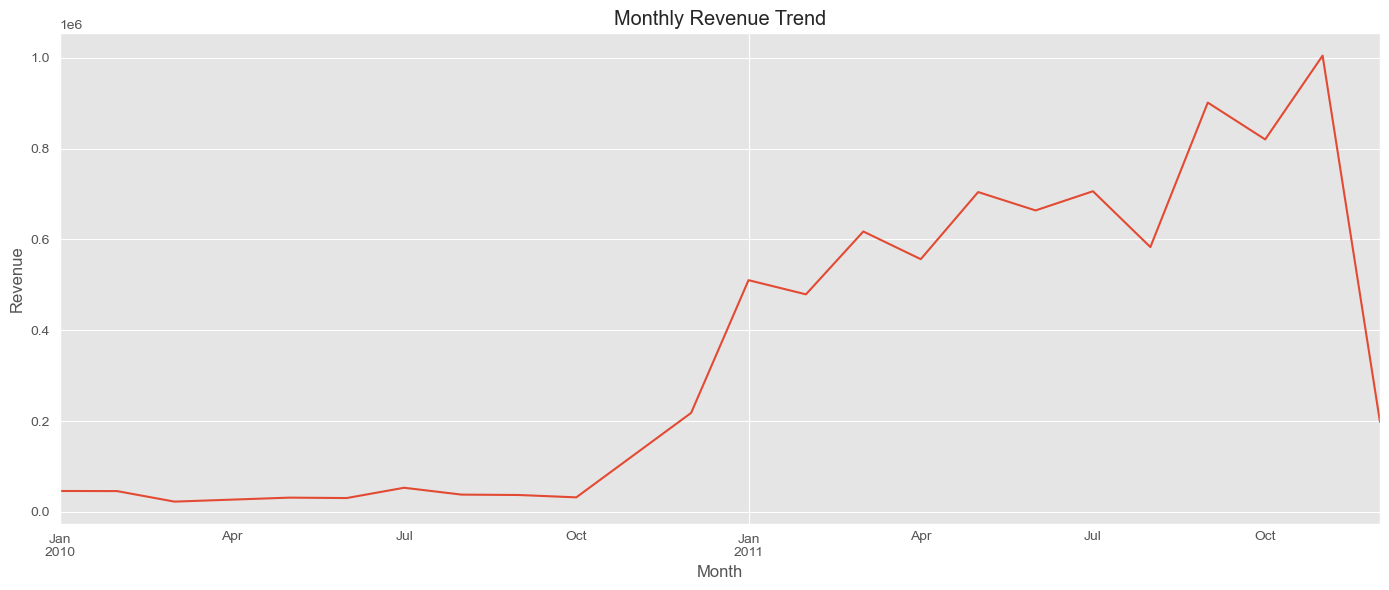

In [31]:
plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.tight_layout()
plt.savefig("monthly_sales.png")
plt.show()

In [32]:
#Top Customers
top_customers = (
    df.groupby('Customer ID')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers)

Customer ID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
14156.0    113384.14
17511.0     88125.38
16684.0     65892.08
13694.0     62653.10
15311.0     59419.34
Name: Revenue, dtype: float64


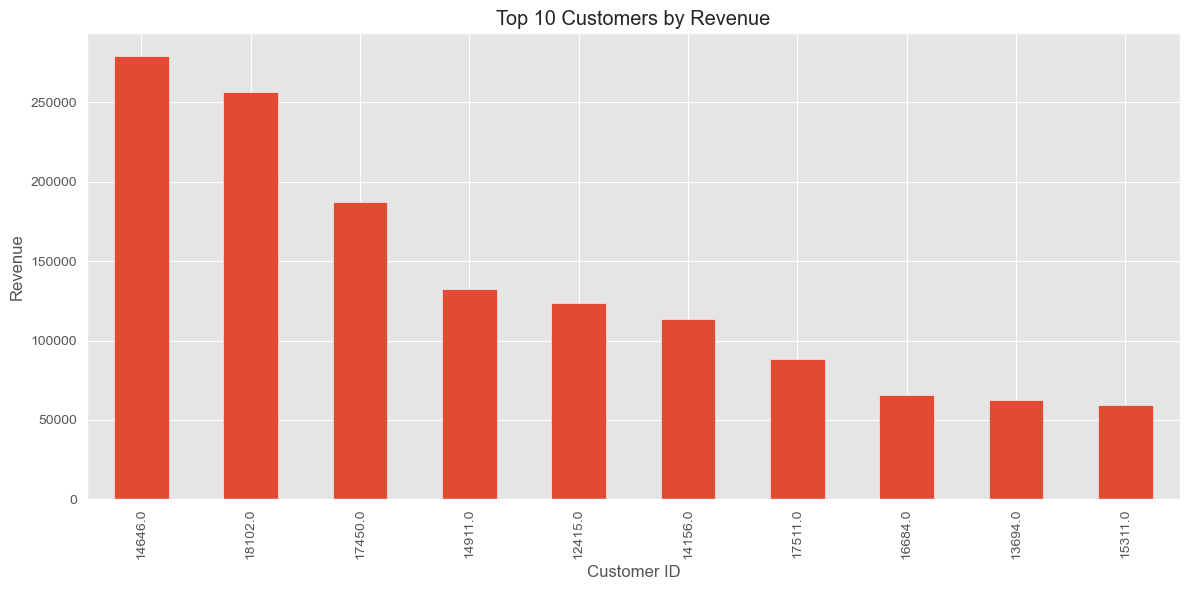

In [33]:
plt.figure(figsize=(12,6))

top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.tight_layout()
plt.savefig("top_customers.png")
plt.show()

In [ ]:
BUSINESS INSIGHTS

1. A small number of products contribute significantly to total sales.

2. Revenue is concentrated in a few countries.

3. Certain customers generate a large share of revenue.

4. Sales show monthly fluctuations indicating seasonal demand.

5. Top-selling products should be prioritized for inventory management.